# Analyse this naive k curve - constant k

- get average endpoints, average hashes, average reductions

## Imports

In [1]:
import numpy as np
import pandas as pd

t = 10000

## Get data 

In [3]:
## cherry m values
cherry_m_values = []

# read in from each directory the m_values and append to cherry_m_values
for i in range(10):
    # Assuming m_values are stored in a file named 'm_values_{i}.npy'
    m_values = np.load(f'const_k/trial_{i}/m_values.npy')
    cherry_m_values.append(m_values)


## vanilla m values
vanilla_m_values = []
for i in range(10):
    m_values = np.load(f'vanilla/trial_{i}/m_values.npy')
    vanilla_m_values.append(m_values)

In [4]:
# create dataframe with columns "table", "avg. endpoints", "avg. hashes", "avg. reductions"
df = pd.DataFrame(columns=["table", "avg. endpoints", "avg. hashes", "avg. reductions"])

## get cherry data first
cherry_avg_mt = np.mean([cherry[-1] for cherry in cherry_m_values])
cherry_avg_hashes = np.mean([np.sum(cherry[:-1]) for cherry in cherry_m_values])
cherry_avg_reductions = np.mean([np.sum(cherry[:-1] * 100) for cherry in cherry_m_values])  # since k_i = 100
# df = df.concat({"table": "cherry", "avg. endpoints": cherry_avg_mt, "avg. hashes": cherry_avg_hashes, "avg. reductions": cherry_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "cherry", 
    "avg. endpoints": cherry_avg_mt, 
    "avg. hashes": cherry_avg_hashes, 
    "avg. reductions": cherry_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

## get vanilla data
vanilla_avg_mt = np.mean([vanilla[-1] for vanilla in vanilla_m_values])
vanilla_avg_hashes = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])
vanilla_avg_reductions = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])  # since k_i = 1
# df = df.append({"table": "vanilla", "avg. endpoints": vanilla_avg_mt, "avg. hashes": vanilla_avg_hashes, "avg. reductions": vanilla_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "vanilla", 
    "avg. endpoints": vanilla_avg_mt, 
    "avg. hashes": vanilla_avg_hashes, 
    "avg. reductions": vanilla_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

display(df)

C:\Users\Mahfuzah Fariha\AppData\Local\Temp\ipykernel_1312\790874731.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


,table,avg. endpoints,avg. hashes,avg. reductions
0,cherry,934067.6,2.684997e+10,2.684997e+12
1,vanilla,815992.4,2.573525e+10,2.573525e+10


In [5]:
## total cost
total_cost_cherry = cherry_avg_hashes + (cherry_avg_reductions * (1/19.26))
total_cost_vanilla = vanilla_avg_hashes

print(f"Total cost of cherry: {total_cost_cherry}")
print(f"Total cost of vanilla: {total_cost_vanilla}")

print(total_cost_cherry / total_cost_vanilla)

Total cost of cherry: 166257922809.67017
Total cost of vanilla: 25735247305.0
6.460319609105468


C:\Users\Mahfuzah Fariha\AppData\Local\Temp\ipykernel_1312\3104561071.py:16: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


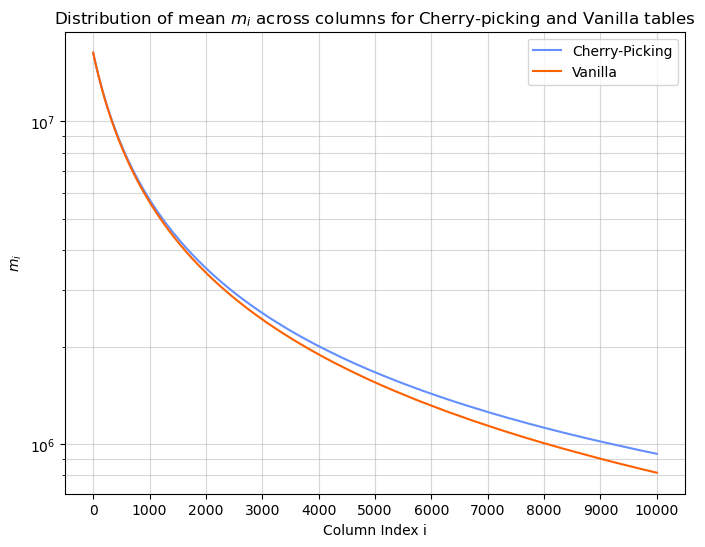

In [17]:
## Plot m_values for cherry and vanilla
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)

ax = plt.gca()
ax.set_yscale('log')
ax.set_ylim(bottom=0)

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

In [32]:
# # hash operations in one column
# from math import prod
# def c_c(t, c, m, N):
#         product = prod(1 - m[i] / N for i in range(c, t + 1))
#         return t - c * product

# # cost of search 
# def T_cost(ell, m_t, N, t, m):

#         # Compute all C_c values (1-indexed)
#         C_vals = [0]  # dummy so C_vals[1] = C_1
#         for c in range(1, t + 1):
#                 C_vals.append(c_c(c, t, m, N))

#         # First summation
#         first_sum = 0
#         for c in range(1, t + 1):

#                 inner_sum = sum(C_vals[t - j + 1] for j in range(1, c + 1))

#                 first_sum += (
#                 (m_t / N)
#                 * (1 - m_t / N) ** (ell * (c - 1))
#                 * inner_sum
#                 )

#         # Second summation
#         second_sum = (1 - m_t / N) ** t * sum(C_vals[1:])

#         return ell * first_sum + ell * second_sum

# print(T_cost(1, cherry_m_values_array[-1], 2**32, t, cherry_m_values_array))

import math
from functools import reduce


def compute_C(c, t, m, N):
    """
    Equation (12): C_c = t - c * prod_{i=c}^{t} (1 - m_i / N)

    Parameters:
        c : int   - lower index (current value of c)
        t : int   - upper limit of the product
        m : list  - list of m values, m[i] gives m_i (1-indexed assumed)
        N : float - total population / normalisation constant
    """
    product = math.prod(1 - m[i] / N for i in range(c, t + 1))
    return t - c * product


def compute_T(t, m, N, ell):
    """
    Equation (13):
    T = ell * sum_{c=1}^{t} [ (m_t/N) * (1 - m_t/N)^{ell*(c-1)} * sum_{j=1}^{c} C_{t-j+1} ]
      + ell * (1 - m_t/N)^t * sum_{c=1}^{t} C_c

    Parameters:
        t   : int   - time step / upper limit
        m   : list  - list of m values, 1-indexed (m[0] unused or m[1]..m[t])
        N   : float - normalisation constant
        ell : float - ell (ℓ) parameter
    """
    m_t = m[-1]
    ratio = m_t / N
    q = 1 - ratio  # (1 - m_t / N)

    # Precompute C values: C_c for c = 1..t
    C = {c: compute_C(c, t, m, N) for c in range(1, t + 1)}

    # First sum: sum_{c=1}^{t} (m_t/N) * q^{ell*(c-1)} * sum_{j=1}^{c} C_{t-j+1}
    first_sum = 0.0
    for c in range(1, t + 1):
        inner_sum = sum(C[t - j + 1] for j in range(1, c + 1))
        first_sum += ratio * (q ** (ell * (c - 1))) * inner_sum

    # Second term: ell * q^t * sum_{c=1}^{t} C_c
    second_term = (q ** t) * sum(C[c] for c in range(1, t + 1))

    return ell * first_sum + ell * second_term

print(compute_T(t, vanilla_m_values_array, 2**32, 4 ))

48222913.543349765


[100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


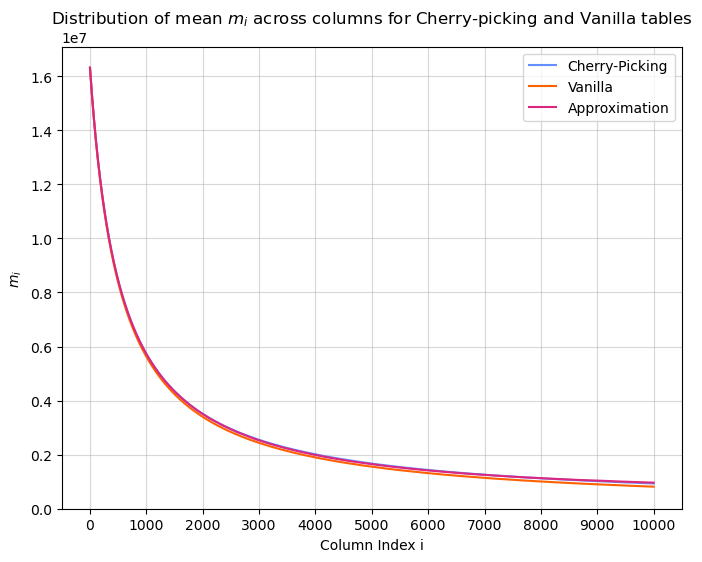

In [71]:
## add on approx
from math import sqrt, pi
from statistics import NormalDist

def calculate_m0(N, t, alpha):
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

def get_mean(N, m):
    return N - (N * ((1 - 1/N) ** m))

def get_std(N, m):
    # E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m
    
    sqrt_term = (N * ((N - 1) * E2 + E1 - N * E1 ** 2))
    if (sqrt_term < 0):
        return 0
    else:
        return sqrt(sqrt_term)


def approx_mi(N, m, k):
    average = get_mean(N, m)
    sd = get_std(N, m)
    # make a normal distribution from these
    # s = np.random.normal(average, sd, k)
    # # sample k random values from this distribution and take the maximum
    # return max(s)

    m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
    # m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
    return m

# Table with the approximation of the occupancy problem
def table_approx(N, t, alpha, k_values):
    m0 = round(calculate_m0(N, t, alpha))
    print(f"m0: {m0}")
    m_values = [m0]
    m = m0

    for i in range(t):
        m = approx_mi(N, m, k_values[i])
        m_values.append(m)

    return m_values

## Plot m_values for cherry and vanilla

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)


# # plot on approx
k_values = [100] * t
print(k_values)
approx_m_values = table_approx(2**32, 10000, 0.95, [100] * t)
# append 9000 0s to the end of approx_m_values to make it the same length as cherry and vanilla m values
approx_m_values = approx_m_values + [0] * (t + 1 - len(approx_m_values))
plt.plot(x_indicies, approx_m_values, color='#dc267f', label="Approximation", markersize=5)


ax = plt.gca()
# ax.set_yscale('log')
ax.set_ylim(bottom=0)

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

In [72]:
print(cherry_m_values_array[4500])

1824592.2


In [23]:
calculate_m0(2**32, 20000, 0.95)

print((2**33) / (25000 + ((2** 33) / 8159622)))

print((2**32) ** (2/3))

329713.32909494144
2642245.949629131


In [24]:
## success prob
ch_sp = 1 - ((1 - (cherry_avg_mt / 2**32)) ** t)
van_sp = 1 - ((1 - (vanilla_avg_mt / 2**32)) ** t)

print(f"Success probability of cherry: {ch_sp}")
print(f"Success probability of vanilla: {van_sp}")

Success probability of cherry: 0.886395496083783
Success probability of vanilla: 0.8504404828304226


In [30]:
def p_ell(p, ell):
    return 1 - ((1 - p) ** ell)

# figure out how many ell it takes to get to 99.97% success probability for both cherry and vanilla
cherry_ell = 0
vanilla_ell = 0


for i in range(1, 7):
    p_cherry_ell = p_ell(ch_sp, i)
    p_vanilla_ell = p_ell(van_sp, i)
    print(f"Success probability of cherry with ell={i}: {p_cherry_ell * 100:.4f}%")
    print(f"Success probability of vanilla with ell={i}: {p_vanilla_ell * 100:.4f}%\n")

Success probability of cherry with ell=1: 88.6395%
Success probability of vanilla with ell=1: 85.0440%

Success probability of cherry with ell=2: 98.7094%
Success probability of vanilla with ell=2: 97.7632%

Success probability of cherry with ell=3: 99.8534%
Success probability of vanilla with ell=3: 99.6655%

Success probability of cherry with ell=4: 99.9833%
Success probability of vanilla with ell=4: 99.9500%

Success probability of cherry with ell=5: 99.9981%
Success probability of vanilla with ell=5: 99.9925%

Success probability of cherry with ell=6: 99.9998%
Success probability of vanilla with ell=6: 99.9989%



[100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,

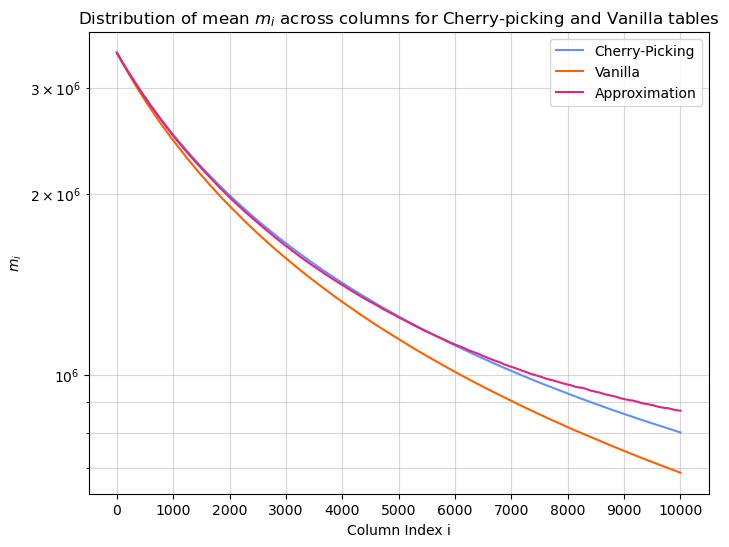

In [6]:
## add on approx
from math import sqrt, pi
from statistics import NormalDist

def calculate_m0(N, t, alpha):
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

def get_mean(N, m):
    return N - (N * ((1 - 1/N) ** m))

def get_std(N, m):
    # E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m
    
    sqrt_term = (N * ((N - 1) * E2 + E1 - N * E1 ** 2))
    if (sqrt_term < 0):
        return 0
    else:
        return sqrt(sqrt_term)


def approx_mi(N, m, k):
    average = get_mean(N, m)
    sd = get_std(N, m)
    # make a normal distribution from these
    # s = np.random.normal(average, sd, k)
    # # sample k random values from this distribution and take the maximum
    # return max(s)

    m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
    # m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
    return m

# Table with the approximation of the occupancy problem
def table_approx(N, t, alpha, k_values):
    m0 = round(calculate_m0(N, t, alpha))
    print(f"m0: {m0}")
    m_values = [m0]
    m = m0

    for i in range(t):
        m = approx_mi(N, m, k_values[i])
        m_values.append(m)

    return m_values

## Plot m_values for cherry and vanilla

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)


# # plot on approx
t = 10000
k_values = [100] * t
print(k_values)
approx_m_values = table_approx(2**32, 10000, 0.8, [100] * t)
# append 9000 0s to the end of approx_m_values to make it the same length as cherry and vanilla m values
plt.plot(x_indicies, approx_m_values, color='#dc267f', label="Approximation", markersize=5)


ax = plt.gca()
ax.set_yscale('log')

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
# plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


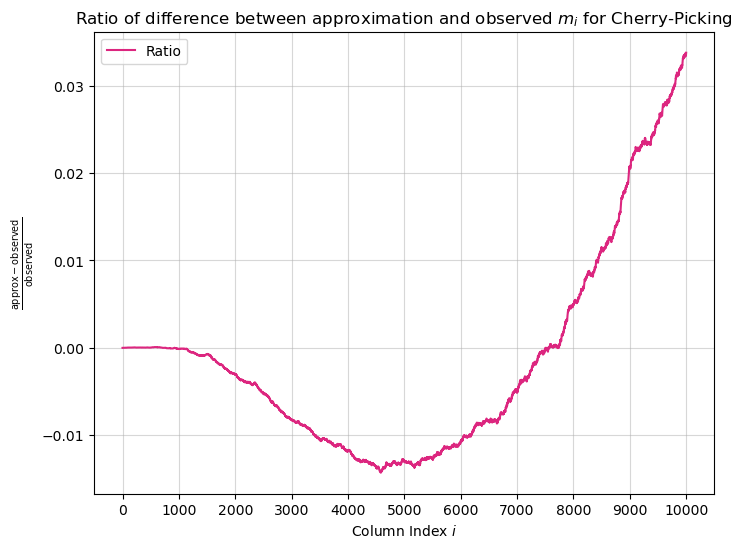

In [39]:
## plot ratio of difference between approximation and cherry-picking 
ratios = []
for i in range(len(cherry_m_values_array)):
    ratio = (approx_m_values[i] - cherry_m_values_array[i]) / cherry_m_values_array[i]
    ratios.append(ratio)

# use box plots and calculate ratio for each trial and plot the distribution of ratios for each column index
# for i in range(len(cherry_m_values_array)):
#     ratio = []
#     for j in range(len(cherry_m_values)):
#         ratio.append((approx_m_values[i] - cherry_m_values[j][i]) / cherry_m_values[j][i])
#     ratios.append(ratio)




plt.figure(figsize=(8, 6))
plt.plot(x_indicies, ratios, color='#dc267f', label="Ratio")
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)
plt.xlabel("Column Index $i$")
plt.ylabel(r"$\frac{\text{approx} - \text{observed}}{\text{observed}}$")
plt.title(r"Ratio of difference between approximation and observed $m_i$ for Cherry-Picking")
plt.legend()
plt.savefig(f"approximation_ratio_n_32.eps", format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


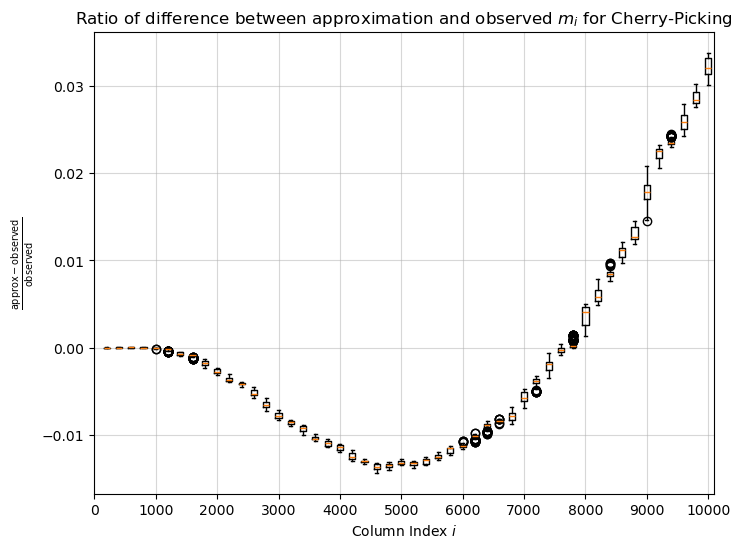

In [69]:
# relative_error = (approx_m_values - cherry_m_values_array) / cherry_m_values_array  # shape (10, 20)

# # Plot — each column becomes one box
# fig, ax = plt.subplots(figsize=(14, 6))
# ax.boxplot(relative_error, labels=range(0, 10002))

# ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero error')
# ax.set_xlabel('Value index')
# ax.set_ylabel('(Expected − Observed) / Observed')
# ax.set_title('Relative error across 10 trials')
# ax.legend()
# plt.tight_layout()
# plt.show()

n_bins = 50  # adjust as needed
relative_error = (approx_m_values - cherry_m_values_array) / cherry_m_values_array  # shape (20, 10001)
# transpose to shape (10001, 20) so that each column corresponds to a value index
relative_error = relative_error.reshape(1, -1)  # shape (1, 10001)

# Split into bins across the value axis
bins = np.array_split(relative_error, n_bins, axis=1)
binned = [b.flatten() for b in bins]  # pool all trials within each bin

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(binned)
# ax.xaxis.set_major_locator(MultipleLocator(5))
# ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x) * 200}'))
tick_positions = range(0, n_bins + 1, 5)  # 0, 5, 10, ..., 50
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(t * 200) for t in tick_positions])
plt.xlabel("Column Index $i$")
plt.ylabel(r"$\frac{\text{approx} - \text{observed}}{\text{observed}}$")
plt.title(r"Ratio of difference between approximation and observed $m_i$ for Cherry-Picking")
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)
plt.savefig(f"approximation_ratio_n_32_binned.eps", format='eps', bbox_inches='tight')
plt.show()


In [70]:
# print max of boxplot in column 10001
print(f"Max relative error in last column: {max(binned[-1])}")

Max relative error in last column: 0.033750133270882346


## plot on all 3 naive k curves



[100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,

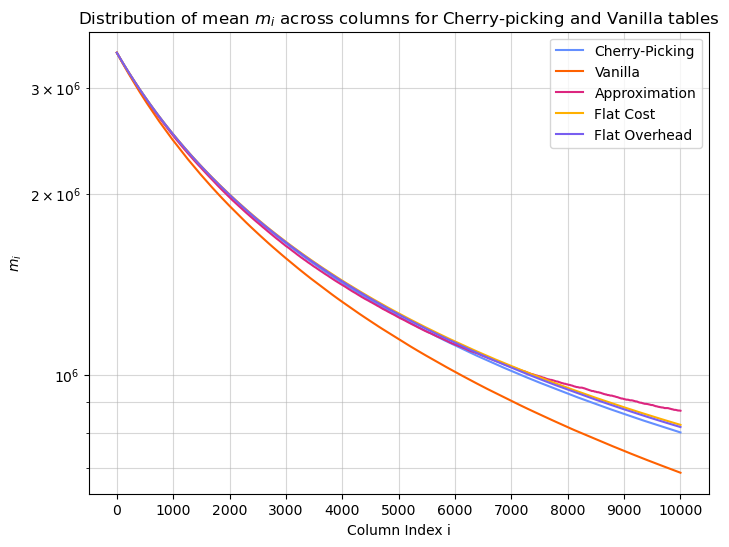

In [8]:
## add on approx
# from math import sqrt, pi
# from statistics import NormalDis

## Plot m_values for cherry and vanilla

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)


# # plot on approx
t = 10000
k_values = [100] * t
print(k_values)
approx_m_values = table_approx(2**32, 10000, 0.8, [100] * t)
# append 9000 0s to the end of approx_m_values to make it the same length as cherry and vanilla m values
plt.plot(x_indicies, approx_m_values, color='#dc267f', label="Approximation", markersize=5)

# plot on flat cost
flat_cost_avg_m_values = np.mean(flat_cost_m_values, axis=0)
plt.plot(x_indicies, flat_cost_avg_m_values, color='#ffb000', label="Flat Cost", markersize=5)

# plot on flat overhead
flat_overhead_avg_m_values = np.mean(flat_overhead_m_values, axis=0)
plt.plot(x_indicies, flat_overhead_avg_m_values, color='#785ef0', label="Flat Overhead", markersize=5)


ax = plt.gca()
ax.set_yscale('log')

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
# plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

In [12]:
## success prob
ch_sp = 1 - ((1 - (cherry_avg_mt / 2**32)) ** t)
curve_sp = 1 - ((1 - (curve_avg_mt / 2**32)) ** t)
van_sp = 1 - ((1 - (vanilla_avg_mt / 2**32)) ** t)

print(f"Success probability of cherry: {ch_sp}")
print(f"Success probability of k-curve: {curve_sp}")
print(f"Success probability of vanilla: {van_sp}")

Success probability of cherry: 0.8451518617321353
Success probability of k-curve: 0.8458618498933477
Success probability of vanilla: 0.7977652561436454


In [13]:
def p_ell(p, ell):
    return 1 - ((1 - p) ** ell)

# figure out how many ell it takes to get to 99.97% success probability for both cherry and vanilla
cherry_ell = 0
curve_ell = 0
vanilla_ell = 0


for i in range(1, 7):
    p_cherry_ell = p_ell(ch_sp, i)
    p_curve_ell = p_ell(curve_sp, i)
    p_vanilla_ell = p_ell(van_sp, i)
    print(f"Success probability of cherry with ell={i}: {p_cherry_ell * 100:.4f}%")
    print(f"Success probability of k-curve with ell={i}: {p_curve_ell * 100:.4f}%")
    print(f"Success probability of vanilla with ell={i}: {p_vanilla_ell * 100:.4f}%\n")

Success probability of cherry with ell=1: 84.5152%
Success probability of k-curve with ell=1: 84.5862%
Success probability of vanilla with ell=1: 79.7765%

Success probability of cherry with ell=2: 97.6022%
Success probability of k-curve with ell=2: 97.6241%
Success probability of vanilla with ell=2: 95.9101%

Success probability of cherry with ell=3: 99.6287%
Success probability of k-curve with ell=3: 99.6338%
Success probability of vanilla with ell=3: 99.1729%

Success probability of cherry with ell=4: 99.9425%
Success probability of k-curve with ell=4: 99.9436%
Success probability of vanilla with ell=4: 99.8327%

Success probability of cherry with ell=5: 99.9911%
Success probability of k-curve with ell=5: 99.9913%
Success probability of vanilla with ell=5: 99.9662%

Success probability of cherry with ell=6: 99.9986%
Success probability of k-curve with ell=6: 99.9987%
Success probability of vanilla with ell=6: 99.9932%



1185213.8817791939
1186884.8
1185050.364636898
1186752.6
-0.0014098031135931814
-0.0014364244878517216
0.9814669169986412


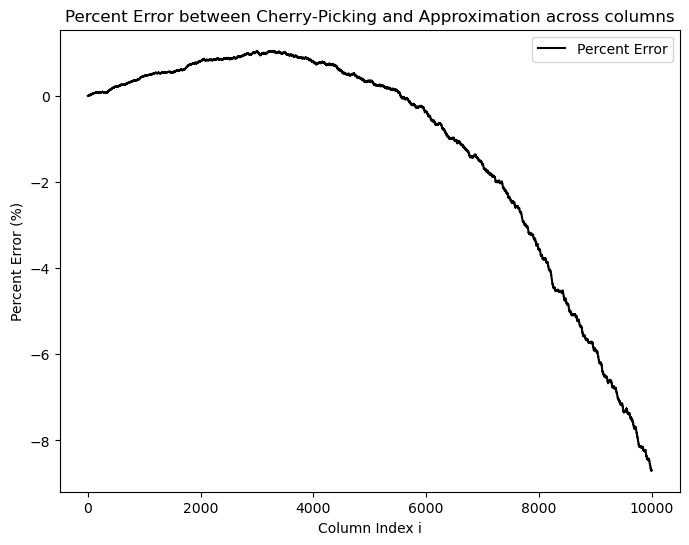

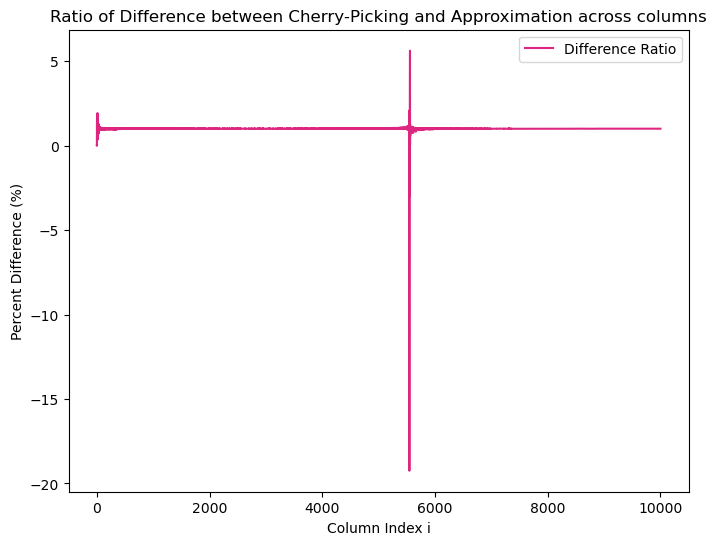

In [ ]:
# # find percent error between columns of cherry and approx
# points_df = pd.DataFrame({
#     "cherry": cherry_m_values_array,
#     "approx": approx_m_values
# })

# points_df["percent_error"] = ((points_df["cherry"] - points_df["approx"]) / points_df["cherry"]) * 100

# percent_difference = [0]
# # for i in range(1, len(points_df)):
# #     percent_difference.append(points_df["percent_error"].iloc[i-1] / points_df["percent_error"].iloc[i])
# for i in range(1, len(points_df)):
#     # [(approx_i-baseline_i)/approx_i] / [(approx_{i+1}-baseline_{i+1})/approx._{i+1}]
#     percent_difference.append(((points_df["approx"].iloc[i-1] - points_df["cherry"].iloc[i-1] ) / points_df["approx"].iloc[i-1]) / ((points_df["approx"].iloc[i] - points_df["cherry"].iloc[i]) / points_df["approx"].iloc[i]))
#     if i == 5448:
#         print(points_df["approx"].iloc[i-1])
#         print(points_df["cherry"].iloc[i-1])
#         print(points_df["approx"].iloc[i])
#         print(points_df["cherry"].iloc[i])
#         print(((points_df["approx"].iloc[i-1] - points_df["cherry"].iloc[i-1] ) / points_df["approx"].iloc[i-1]))
#         print(((points_df["approx"].iloc[i] - points_df["cherry"].iloc[i]) / points_df["approx"].iloc[i]))
#         print(((points_df["approx"].iloc[i-1] - points_df["cherry"].iloc[i-1] ) / points_df["approx"].iloc[i-1]) / ((points_df["approx"].iloc[i] - points_df["cherry"].iloc[i]) / points_df["approx"].iloc[i]))


# points_df["percent_difference"] = percent_difference

# # import numpy as np

# # # 1. Calculate the relative error for all rows at once
# # # We add a tiny epsilon (e.g., 1e-15) if there's any chance approx itself is 0
# # numerator_err = (points_df["approx"] - points_df["cherry"]) / points_df["approx"]

# # # 2. Shift the series to get the "next" row's error for the denominator
# # # This aligns row i with row i+1
# # denominator_err = numerator_err.shift(-1)

# # # 3. Handle the near-zero division safely
# # # If the denominator error is extremely close to 0, replace it with NaN or 0 to prevent inf
# # epsilon = 1e-12 
# # safe_denominator = np.where(np.abs(denominator_err) < epsilon, np.nan, denominator_err)

# # # 4. Calculate the final ratio
# # points_df["percent_difference_ratio"] = numerator_err / safe_denominator

# # plot percent error across columns
# plt.figure(figsize=(8, 6))
# plt.plot(x_indicies, points_df["percent_error"], color='#000000', label="Percent Error", markersize=5)
# plt.xlabel("Column Index i")
# plt.ylabel("Percent Error (%)")
# plt.title("Percent Error between Cherry-Picking and Approximation across columns")
# plt.legend()
# plt.show()

# # plot percent difference across columns
# plt.figure(figsize=(8, 6))
# plt.plot(x_indicies, points_df["percent_difference"], color='#dc267f', label="Difference Ratio", markersize=5)
# plt.xlabel("Column Index i")
# plt.ylabel("Percent Difference (%)")
# plt.title("Ratio of Difference between Cherry-Picking and Approximation across columns")
# plt.legend()
# plt.show()